# RPG Performance Analysis (Sports)

This notebook loads the Sports-only profiling artifacts from both the shared group artifacts tree and the repo-local home artifacts tree, then summarizes the latest available profiling session and graph-validation report.

Expected layouts:

```text
<artifact-root>/rpg/perf/sports/<session>/manifest.json
<artifact-root>/rpg/perf/sports/<session>/summaries/profile_summary.csv
<artifact-root>/rpg/perf/sports/<session>/graphs/validate_graph_report.json
```

The shared graph cache directory `<artifact-root>/rpg/perf/sports/graphs/` is also discovered indirectly through each session manifest.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd().resolve()
while ROOT.name != "RPG":
    ROOT = ROOT.parent

HOME_ARTIFACT_ROOT = ROOT / "artifacts" / "rpg" / "perf" / "sports"
GROUP_ARTIFACT_ROOT = Path("/projects/prjs2120/groups/group_16/artifacts/rpg/perf/sports")
ARTIFACT_ROOTS = []
for candidate in (GROUP_ARTIFACT_ROOT, HOME_ARTIFACT_ROOT):
    if candidate not in ARTIFACT_ROOTS:
        ARTIFACT_ROOTS.append(candidate)

# If you run this notebook from another working directory, override one or both manually.
# HOME_ARTIFACT_ROOT = Path("/gpfs/home6/$USER/RPG/artifacts/rpg/perf/sports").expanduser()
# GROUP_ARTIFACT_ROOT = Path("/projects/prjs2120/groups/group_16/artifacts/rpg/perf/sports")

ARTIFACT_ROOTS


[PosixPath('/projects/prjs2120/groups/group_16/artifacts/rpg/perf/sports'),
 PosixPath('/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports')]

In [2]:
def _read_json(path: Path):
    return json.loads(path.read_text())


def _safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.is_file() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)


def _decorate_frame(frame: pd.DataFrame, **metadata) -> pd.DataFrame:
    if frame.empty:
        return frame
    result = frame.copy()
    for key, value in metadata.items():
        result[key] = value
    return result


def load_perf_artifacts():
    manifest_rows = []
    summary_frames = []
    graph_frames = []
    validation_rows = []
    validation_graph_rows = []

    for artifact_root in ARTIFACT_ROOTS:
        if not artifact_root.exists():
            continue

        for manifest_path in sorted(artifact_root.rglob("manifest.json")):
            session_root = manifest_path.parent.resolve()
            payload = _read_json(manifest_path)

            summary_path = Path(payload.get("summary_csv", session_root / "summaries" / "profile_summary.csv"))
            raw_path = Path(payload.get("raw_csv", session_root / "raw" / "profile_runs.csv"))
            graph_path = Path(payload.get("graph_csv", session_root / "graphs" / "graph_builds.csv"))

            manifest_rows.append(
                {
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "manifest_path": str(manifest_path),
                    "summary_path": str(summary_path),
                    "raw_path": str(raw_path),
                    "graph_path": str(graph_path),
                    "has_summary_csv": summary_path.is_file(),
                    "has_raw_csv": raw_path.is_file(),
                    "has_graph_csv": graph_path.is_file(),
                }
            )

            summary_df = _safe_read_csv(summary_path)
            summary_frames.append(
                _decorate_frame(
                    summary_df,
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    summary_path=str(summary_path),
                    raw_path=str(raw_path),
                    graph_path=str(graph_path),
                )
            )

            graph_df = _safe_read_csv(graph_path)
            graph_frames.append(
                _decorate_frame(
                    graph_df,
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    graph_path=str(graph_path),
                )
            )

        for report_path in sorted(artifact_root.rglob("validate_graph_report.json")):
            session_root = report_path.parents[1].resolve()
            payload = _read_json(report_path)
            comparisons = payload.get("comparisons", {})
            validation_rows.append(
                {
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "report_path": str(report_path),
                    "paper_md_path": str(report_path.with_name("paper.md")),
                    "checkpoint_path": payload.get("checkpoint_path"),
                    "checkpoint_name": None if payload.get("checkpoint_path") is None else Path(payload["checkpoint_path"]).name,
                    "checkpoint_signature": payload.get("checkpoint_signature"),
                    "pool_size": payload.get("pool_size"),
                    "topk": payload.get("topk"),
                    "dense_vs_flat_mean_overlap": comparisons.get("dense_vs_flat", {}).get("mean_overlap_rate"),
                    "dense_vs_flat_exact_match_rate": comparisons.get("dense_vs_flat", {}).get("exact_match_rate"),
                    "flat_vs_hnsw_mean_overlap": comparisons.get("flat_vs_hnsw", {}).get("mean_overlap_rate"),
                    "flat_vs_hnsw_p50_overlap": comparisons.get("flat_vs_hnsw", {}).get("p50_overlap_rate"),
                    "dense_vs_hnsw_mean_overlap": comparisons.get("dense_vs_hnsw", {}).get("mean_overlap_rate"),
                    "dense_vs_hnsw_p50_overlap": comparisons.get("dense_vs_hnsw", {}).get("p50_overlap_rate"),
                }
            )
            for graph_record in payload.get("graph_records", []):
                validation_graph_rows.append(
                    {
                        "artifact_root": str(artifact_root),
                        "session": session_root.name,
                        "session_root": str(session_root),
                        "report_path": str(report_path),
                        **graph_record,
                    }
                )

    manifest_index = pd.DataFrame(manifest_rows).sort_values(["session", "artifact_root"]).reset_index(drop=True) if manifest_rows else pd.DataFrame()
    profile_summaries = pd.concat([frame for frame in summary_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in summary_frames) else pd.DataFrame()
    graph_builds = pd.concat([frame for frame in graph_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in graph_frames) else pd.DataFrame()
    validation_runs = pd.DataFrame(validation_rows).sort_values(["session", "artifact_root"]).reset_index(drop=True) if validation_rows else pd.DataFrame()
    validation_graphs = pd.DataFrame(validation_graph_rows).sort_values(["session", "backend"]).reset_index(drop=True) if validation_graph_rows else pd.DataFrame()
    return manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs


In [3]:
manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs = load_perf_artifacts()

existing_roots = [str(path) for path in ARTIFACT_ROOTS if path.exists()]
print(
    f"Discovered {len(manifest_index)} profiling sessions and {len(validation_runs)} validation reports across {len(existing_roots)} artifact roots."
)
if existing_roots:
    print("Existing artifact roots:")
    for root in existing_roots:
        print(f"  - {root}")

if manifest_index.empty:
    print("No manifest.json files found under the configured perf artifact roots.")
else:
    display(
        manifest_index[
            [
                "session",
                "artifact_root",
                "has_summary_csv",
                "has_raw_csv",
                "has_graph_csv",
                "summary_path",
            ]
        ].sort_values(["session", "artifact_root"], ascending=[False, True]).reset_index(drop=True)
    )


Discovered 1 profiling sessions and 1 validation reports across 1 artifact roots.
Existing artifact roots:
  - /gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports


,session,artifact_root,has_summary_csv,has_raw_csv,has_graph_csv,summary_path
0,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,True,True,True,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...


## Latest Profiling Session

This table keeps the latest discovered profiling session and shows the per-pool median latency, CUDA memory, traversal, and `NDCG@10` measurements.


In [4]:
if profile_summaries.empty:
    print("No profile summary rows available.")
else:
    latest_profile_session = (
        profile_summaries[["artifact_root", "session", "session_root", "checkpoint_signature"]]
        .drop_duplicates()
        .sort_values(["session", "artifact_root"])
        .tail(1)
        .iloc[0]
    )
    latest_profile_rows = (
        profile_summaries[profile_summaries["session_root"] == latest_profile_session["session_root"]]
        .sort_values("pool_size")
        .reset_index(drop=True)
    )
    latest_profile_summary = latest_profile_rows[
        [
            "session",
            "artifact_root",
            "pool_size",
            "graph_backend",
            "epoch_time_s_median",
            "peak_cuda_runtime_delta_allocated_gb_median",
            "peak_cuda_allocated_gb_median",
            "visited_ratio_median",
            "n_visited_items_median",
            "ndcg_at_10_median",
            "checkpoint_signature",
        ]
    ].copy()
    display(
        latest_profile_summary.style.format(
            {
                "epoch_time_s_median": "{:.2f}",
                "peak_cuda_runtime_delta_allocated_gb_median": "{:.3f}",
                "peak_cuda_allocated_gb_median": "{:.3f}",
                "visited_ratio_median": "{:.4f}",
                "n_visited_items_median": "{:.1f}",
                "ndcg_at_10_median": "{:.5f}",
            }
        )
    )

    latest_graph_rows = pd.DataFrame()
    if not graph_builds.empty:
        latest_graph_rows = (
            graph_builds[graph_builds["session_root"] == latest_profile_session["session_root"]]
            .sort_values("pool_size")
            .reset_index(drop=True)
        )
    if latest_graph_rows.empty:
        print("No graph_builds.csv rows found for the latest profiling session.")
    else:
        display(
            latest_graph_rows[
                [
                    "pool_size",
                    "backend",
                    "topk",
                    "build_seconds",
                    "loaded_from_cache",
                    "vector_batch_size",
                    "checkpoint_signature",
                ]
            ].style.format({"build_seconds": "{:.2f}"})
        )


,session,artifact_root,pool_size,graph_backend,epoch_time_s_median,peak_cuda_runtime_delta_allocated_gb_median,peak_cuda_allocated_gb_median,visited_ratio_median,n_visited_items_median,ndcg_at_10_median,checkpoint_signature
0,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,20000,hnsw,37.23,0.103,0.197,0.0798,1595.8,0.01755,783be92f6501
1,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,50000,hnsw,36.30,0.104,0.221,0.0256,1277.6,0.00564,783be92f6501
2,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,100000,hnsw,34.46,0.103,0.265,0.0113,1132.7,0.00173,783be92f6501
3,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,200000,hnsw,34.34,0.104,0.352,0.0053,1066.9,0.00049,783be92f6501
4,20260605T193847131557Z_job23505191,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,500000,hnsw,33.64,0.104,0.612,0.0021,1040.3,0.00014,783be92f6501


,pool_size,backend,topk,build_seconds,loaded_from_cache,vector_batch_size,checkpoint_signature
0,20000,hnsw,100,84.09,True,512,783be92f6501
1,50000,hnsw,100,288.90,True,512,783be92f6501
2,100000,hnsw,100,509.89,True,512,783be92f6501
3,200000,hnsw,100,932.07,True,512,783be92f6501
4,500000,hnsw,100,1668.94,True,512,783be92f6501


## Plot: Scaling Trend

These plots reuse the latest profiling session to show how latency, CUDA memory, and `NDCG@10` move as the candidate pool grows.


**Latest profiling session:** `20260605T193847131557Z_job23505191`

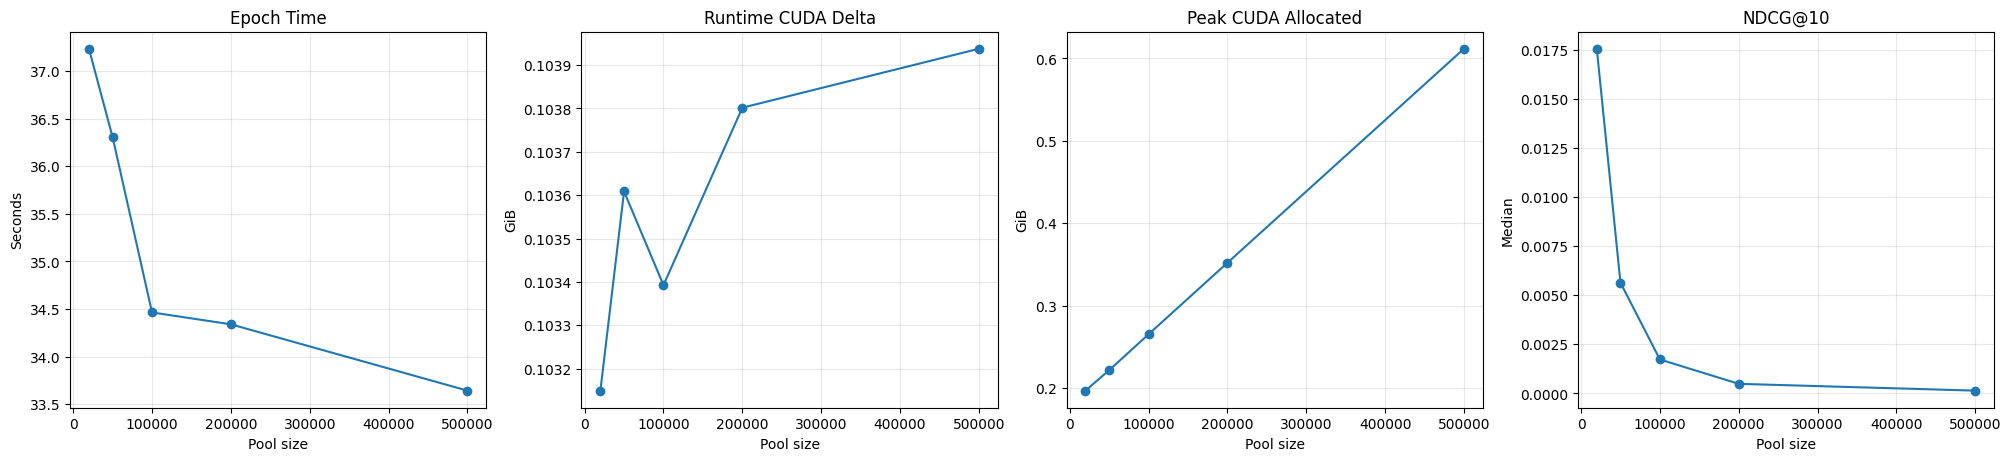

In [5]:
if profile_summaries.empty:
    print("No profiling rows available for plotting.")
else:
    plot_rows = latest_profile_rows.sort_values("pool_size")
    display(Markdown(f"**Latest profiling session:** `{latest_profile_rows['session'].iloc[0]}`"))
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), constrained_layout=True)

    axes[0].plot(plot_rows["pool_size"], plot_rows["epoch_time_s_median"], marker="o")
    axes[0].set_title("Epoch Time")
    axes[0].set_xlabel("Pool size")
    axes[0].set_ylabel("Seconds")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        plot_rows["pool_size"],
        plot_rows["peak_cuda_runtime_delta_allocated_gb_median"],
        marker="o",
    )
    axes[1].set_title("Runtime CUDA Delta")
    axes[1].set_xlabel("Pool size")
    axes[1].set_ylabel("GiB")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(plot_rows["pool_size"], plot_rows["peak_cuda_allocated_gb_median"], marker="o")
    axes[2].set_title("Peak CUDA Allocated")
    axes[2].set_xlabel("Pool size")
    axes[2].set_ylabel("GiB")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(plot_rows["pool_size"], plot_rows["ndcg_at_10_median"], marker="o")
    axes[3].set_title("NDCG@10")
    axes[3].set_xlabel("Pool size")
    axes[3].set_ylabel("Median")
    axes[3].grid(True, alpha=0.3)

    plt.show()


## Latest Graph-Validation Report

If a `validate_graph_report.json` session exists, this section shows the latest overlap summary plus the paper-ready text snippet written by the validation job.


In [6]:
if validation_runs.empty:
    print("No validate_graph_report.json files found.")
else:
    latest_validation = (
        validation_runs.sort_values(["session", "artifact_root"])
        .tail(1)
        .reset_index(drop=True)
    )
    display(
        latest_validation[
            [
                "session",
                "artifact_root",
                "pool_size",
                "topk",
                "checkpoint_signature",
                "dense_vs_flat_mean_overlap",
                "dense_vs_flat_exact_match_rate",
                "flat_vs_hnsw_mean_overlap",
                "flat_vs_hnsw_p50_overlap",
                "dense_vs_hnsw_mean_overlap",
                "dense_vs_hnsw_p50_overlap",
            ]
        ].style.format(
            {
                "dense_vs_flat_mean_overlap": "{:.4%}",
                "dense_vs_flat_exact_match_rate": "{:.4%}",
                "flat_vs_hnsw_mean_overlap": "{:.4%}",
                "flat_vs_hnsw_p50_overlap": "{:.2%}",
                "dense_vs_hnsw_mean_overlap": "{:.4%}",
                "dense_vs_hnsw_p50_overlap": "{:.2%}",
            }
        )
    )

    latest_validation_row = latest_validation.iloc[0]
    latest_validation_graphs = (
        validation_graphs[validation_graphs["session_root"] == latest_validation_row["session_root"]]
        .sort_values("backend")
        .reset_index(drop=True)
    )
    if not latest_validation_graphs.empty:
        display(
            latest_validation_graphs[
                [
                    "backend",
                    "pool_size",
                    "topk",
                    "build_seconds",
                    "cached",
                    "graph_hnsw_m",
                    "graph_hnsw_ef_construction",
                    "graph_hnsw_ef_search",
                ]
            ].style.format({"build_seconds": "{:.2f}"}, na_rep="")
        )

    paper_md_path = Path(latest_validation_row["paper_md_path"])
    if paper_md_path.is_file():
        display(Markdown("### Paper-ready summary"))
        display(Markdown(paper_md_path.read_text()))


,session,artifact_root,pool_size,topk,checkpoint_signature,dense_vs_flat_mean_overlap,dense_vs_flat_exact_match_rate,flat_vs_hnsw_mean_overlap,flat_vs_hnsw_p50_overlap,dense_vs_hnsw_mean_overlap,dense_vs_hnsw_p50_overlap
0,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,18357,100,783be92f6501,99.9910%,99.2373%,98.9475%,99.00%,98.9503%,99.00%


,backend,pool_size,topk,build_seconds,cached,graph_hnsw_m,graph_hnsw_ef_construction,graph_hnsw_ef_search
0,flat,18357,100,68.78,False,,,
1,hnsw,18357,100,105.52,False,32.000000,200.000000,256.000000


### Paper-ready summary

To validate the scalable graph construction backend, we measured the top-100 neighbor overlap between alternative graph builders on the original Sports item pool. For each item, overlap is defined as the fraction of neighbors shared between the two top-100 neighbor sets. This metric is less brittle than exact list equality, since small numerical differences or near-ties at the boundary of the top-100 can change one or two neighbors without materially changing the graph structure. The exact FAISS flat backend reproduced the upstream dense graph with a mean top-100 overlap of 99.99%, confirming that our repo-owned exact implementation is faithful to the original graph construction. The HNSW backend, used for scalable enlarged-pool profiling, achieved 98.95% mean top-100 overlap against the exact FAISS flat graph, with median overlap 99% and 5th-percentile overlap 97%. These results indicate that HNSW provides a high-fidelity approximation of the exact item graph while enabling graph construction at larger pool sizes required for the Figure 3 efficiency study.